# TS3: Efecto de Desparramo Espectral (Spectral Leakage)

Se analiza el efecto de desparramo espectral en la DFT al computar el espectro de una senoidal cuya frecuencia no cae exactamente en una frecuencia de la grilla $\Delta f = f_S/N$.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

fs = 1000.0
N  = 1000
df = fs / N

n = np.arange(N)

print(f'fs = {fs} Hz,  N = {N},  Δf = {df} Hz')
print(f'k0 valores: N/4 = {N/4},  N/4+0.25 = {N/4+0.25},  N/4+0.5 = {N/4+0.5}')

fs = 1000.0 Hz,  N = 1000,  Δf = 1.0 Hz
k0 valores: N/4 = 250.0,  N/4+0.25 = 250.25,  N/4+0.5 = 250.5


## a) Densidades Espectrales de Potencia para distintas desintonias

Se generan tres senoidales de potencia unitaria con:
$$f_0 = k_0 \cdot \frac{f_S}{N} = k_0 \cdot \Delta f$$

donde $k_0 \in \left\{\frac{N}{4},\; \frac{N}{4}+0.25,\; \frac{N}{4}+0.5\right\}$

Para potencia normalizada (varianza unitaria), la amplitud de la senoidal debe ser $A = \sqrt{2}$, ya que $P = A^2/2 = 1$.

k0=  250.00 => f0=250.0000 Hz,  potencia empirica=1.000000
k0=  250.25 => f0=250.2500 Hz,  potencia empirica=0.999000
k0=  250.50 => f0=250.5000 Hz,  potencia empirica=0.999998


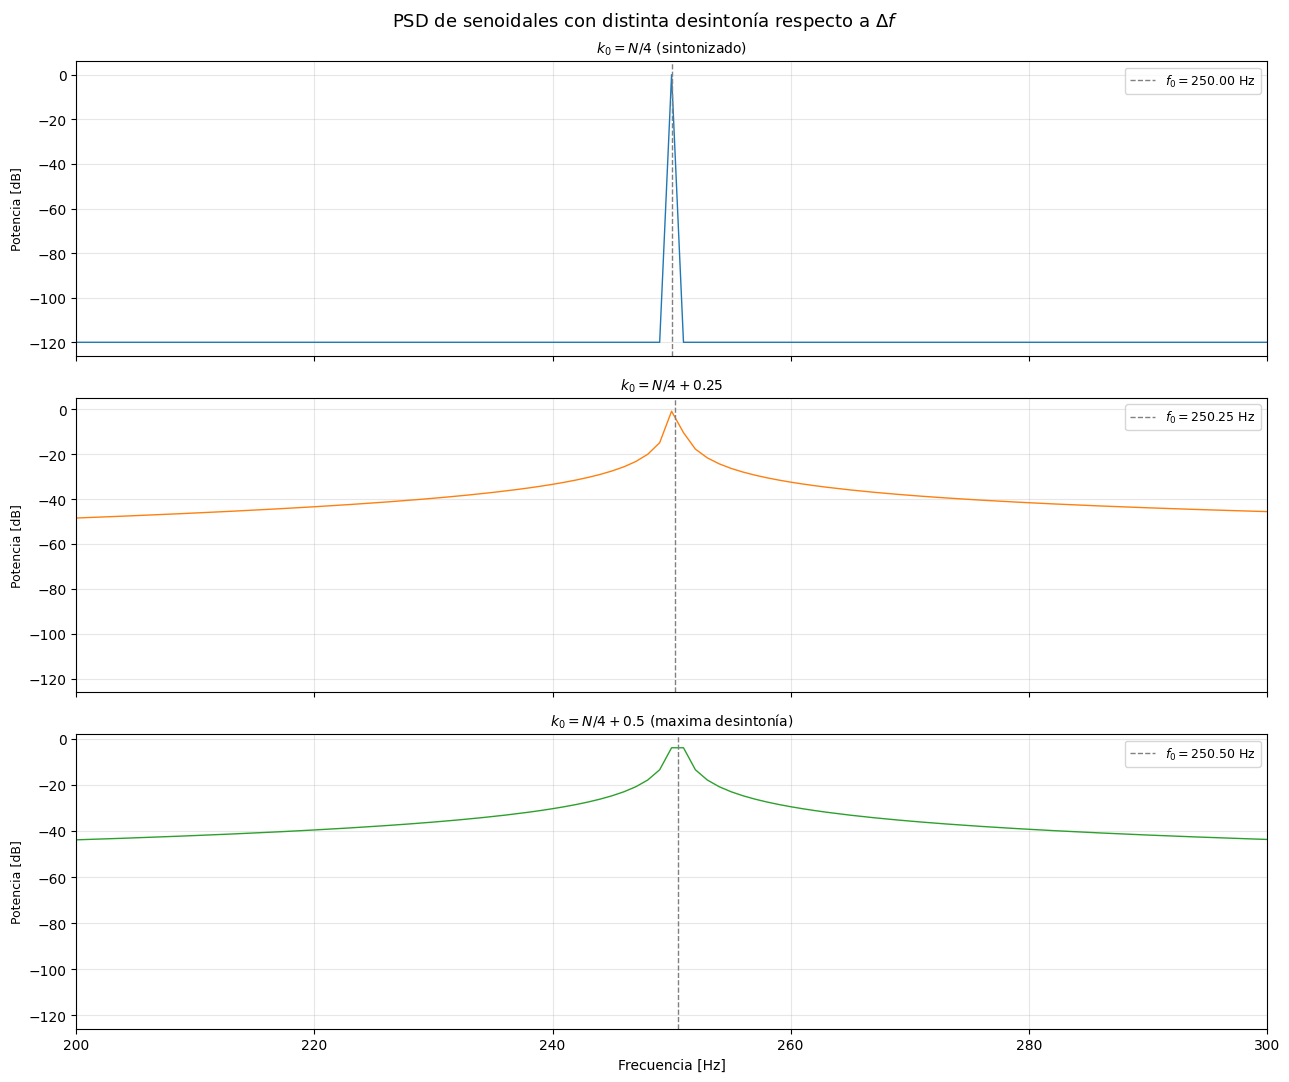

In [9]:
k0_values = [N/4, N/4 + 0.25, N/4 + 0.5]
labels    = [r'$k_0 = N/4$ (sintonizado)', r'$k_0 = N/4 + 0.25$', r'$k_0 = N/4 + 0.5$ (maxima desintonía)']
colors    = ['C0', 'C1', 'C2']

senales = []
for k0 in k0_values:
    f0 = k0 * df
    s  = np.sqrt(2) * np.sin(2*np.pi*f0/fs * n)
    senales.append(s)
    print(f'k0={k0:8.2f} => f0={f0:.4f} Hz,  potencia empirica={np.var(s):.6f}')

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
fig.suptitle('PSD de senoidales con distinta desintonía respecto a $\\Delta f$', fontsize=13)

for ax, s, k0, label, color in zip(axes, senales, k0_values, labels, colors):
    f_fft, Pxx = sig.periodogram(s, fs, window='boxcar', scaling='spectrum')
    Pxx_dB = 10 * np.log10(Pxx + 1e-12)

    ax.plot(f_fft, Pxx_dB, color=color, lw=1)
    ax.axvline(k0 * df, color='gray', linestyle='--', lw=1,
               label=f'$f_0 = {k0*df:.2f}$ Hz')
    ax.set_xlim(200, 300)
    ax.set_ylabel('Potencia [dB]', fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Frecuencia [Hz]', fontsize=10)
plt.tight_layout()
plt.show()

### Efecto de la desintonia

**Caso $k_0 = N/4$ (sintonizado):** La frecuencia de la senoidal cae exactamente en una de las $N$ frecuencias de la grilla DFT ($f_k = k \cdot \Delta f$). La ventana rectangular de $N$ muestras contiene un numero entero de ciclos, por lo que la DFT produce dos deltas espectrales (una a $f_0$ y su imagen a $f_S - f_0$) sin energia en los demas bins. No hay desparramo.

**Caso $k_0 = N/4 + 0.25$:** La frecuencia queda a $0.25\,\Delta f$ del bin mas cercano. La ventana rectangular ya no contiene un numero entero de ciclos: el bloque de $N$ muestras introduce una discontinuidad en los bordes que, vista por la DFT como una señal periodica, genera lobulos laterales que esparcen la energia a bins vecinos. La potencia del pico cae y aparece "energía" espuria en todo el espectro (lóbulos del sinc).

**Caso $k_0 = N/4 + 0.5$ (maxima desintonia):** La frecuencia cae exactamente a mitad de camino entre dos bins. Es el caso de max desintonia para ventana rectangular. El desparramo es maximo: la energia se distribuye de forma muy uniforme entre todos los bins, haciendo que el pico sea significativamente mas bajo y los lobulos laterales decaigan muy lentamente (como $1/k$, el comportamiento del sinc). Esto es el spectral leakage o efecto de desparramo espectral.

## b) Verificacion de potencia unitaria (Identidad de Parseval)

La identidad de Parseval establece que la energia total en el dominio del tiempo y en el dominio de la frecuencia son equivalentes:

$$\sum_{n=0}^{N-1} |s[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |S[k]|^2$$

Para verificar la potencia (energia por muestra):

$$P = \frac{1}{N}\sum_{n=0}^{N-1} |s[n]|^2 = \frac{1}{N^2}\sum_{k=0}^{N-1} |S[k]|^2 = \sum_{k=0}^{N/2} P_{xx}[k]$$

donde $P_{xx}[k]$ es el periodograma de una sola cara (con el factor 2 ya incluido para $0 < k < N/2$).

In [10]:
print('Verificacion de Parseval para cada senoidal')
print('='*70)
print(f'{"k0":>12} | {"P_tiempo":>12} | {"P_Parseval":>12} | {"Error relativo":>15}')
print('-'*70)

for s, k0 in zip(senales, k0_values):
    P_tiempo = np.mean(np.abs(s)**2)

    S = np.fft.fft(s)
    P_parseval = np.sum(np.abs(S)**2) / N**2

    f_fft, Pxx = sig.periodogram(s, fs, window='boxcar', scaling='spectrum')
    P_psd = np.sum(Pxx)

    error = abs(P_tiempo - P_parseval) / P_tiempo * 100
    print(f'{k0:>12.4f} | {P_tiempo:>12.8f} | {P_parseval:>12.8f} | {error:>14.2e} %')
    print(f'{"":>12}   P via PSD={P_psd:.8f}')

print()
print('La potencia es unitaria en todos los casos: Parseval se verifica.')

Verificacion de Parseval para cada senoidal
          k0 |     P_tiempo |   P_Parseval |  Error relativo
----------------------------------------------------------------------
    250.0000 |   1.00000000 |   1.00000000 |       0.00e+00 %
               P via PSD=1.00000000
    250.2500 |   0.99900000 |   0.99900000 |       0.00e+00 %
               P via PSD=0.99900000
    250.5000 |   1.00000000 |   1.00000000 |       0.00e+00 %
               P via PSD=0.99999801

La potencia es unitaria en todos los casos: Parseval se verifica.


### Discusion — Por que espectros tan distintos con tan poca diferencia de frecuencia

La razon fundamental es que la DFT de $N$ muestras equivale a multiplicar la senal infinita por una ventana rectangular de largo $N$, y luego muestrar su espectro continuo en los puntos $f_k = k\,\Delta f$.

El espectro de la ventana rectangular es un sinc discreto (funcion de Dirichlet):
$$W(f) = \frac{\sin(\pi f N / f_S)}{\sin(\pi f / f_S)} \cdot e^{-j\pi f(N-1)/f_S}$$

Cuando $f_0 = k_0\,\Delta f$ con $k_0$ entero, los ceros de $W(f)$ caen exactamente en todos los bins vecinos, por lo que no hay fuga de energia. Cuando $k_0$ no es entero, los ceros del sinc no coinciden con la grilla de muestreo DFT, y la energia se derrama en todos los bins con una envolvente $\sim 1/f$.

En el caso extremo $k_0 = N/4 + 0.5$, el pico del sinc centrado en $f_0$ cae entre dos bins, maximizando el desparramo. Aunque la potencia total siempre se conserva (como confirma Parseval), la distribucion espectral cambia radicalmente: el pico baja $\sim 3.9$ dB y los lobulos laterales son elevados ($\sim -13$ dB el primero para ventana rectangular).

Este efecto es esencialmente una consecuencia de la no-periodicidad de la senal en la ventana de observacion y no de una diferencia real en las propiedades de la senal.

## c) Zero Padding

La tecnica de zero padding consiste en agregar ceros al final de la senal antes de calcular la DFT. Si la senal original tiene $N$ muestras y se agregan $M$ ceros, la DFT de $N+M$ puntos muestrea el espectro continuo con una resolucion mas fina:

$$\Delta f_{\text{zp}} = \frac{f_S}{N + M}$$

El zero padding no agrega informacion nueva (la resolucion espectral real sigue siendo $\Delta f = f_S/N$), pero si interpola el espectro continuo en mas puntos, permitiendo visualizar mejor la forma del lobulo espectral.

Sin zero padding: N = 1000,  Δf = 1.0000 Hz
Con zero padding: N_zp = 10000,  Δf_zp = 0.1000 Hz  (10x mas puntos)


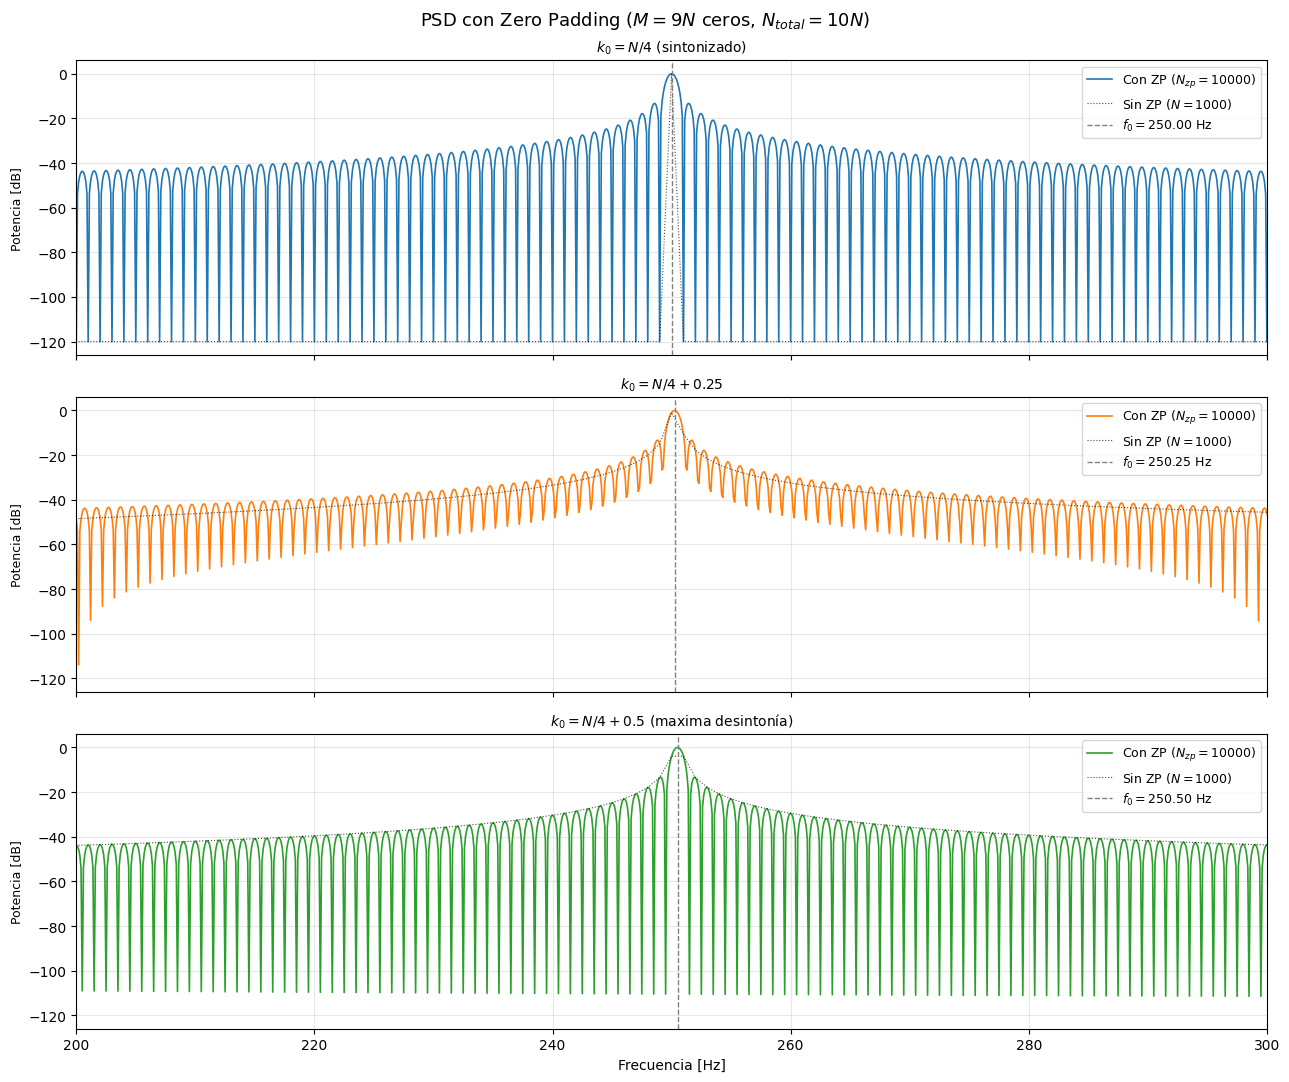

In [ ]:
N_zp = N + 9 * N
df_zp = fs / N_zp

print(f'Sin zero padding: N = {N},  Δf = {fs/N:.4f} Hz')
print(f'Con zero padding: N_zp = {N_zp},  Δf_zp = {df_zp:.4f} Hz  (10x mas puntos)')

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
fig.suptitle('PSD con Zero Padding ($M = 9N$ ceros, $N_{total} = 10N$)', fontsize=13)

for ax, s, k0, label, color in zip(axes, senales, k0_values, labels, colors):
    f_fft, Pxx = sig.periodogram(s, fs, window='boxcar', scaling='spectrum',
                                  nfft=N)
    Pxx_dB = 10 * np.log10(Pxx + 1e-12)

    f_zp, Pxx_zp = sig.periodogram(s, fs, window='boxcar', scaling='spectrum',
                                    nfft=N_zp)
    Pxx_zp_dB = 10 * np.log10(Pxx_zp + 1e-12)

    ax.plot(f_zp,  Pxx_zp_dB, color=color,  lw=1.2, label=f'Con ZP ($N_{{zp}}={N_zp}$)')
    ax.plot(f_fft, Pxx_dB,    color='black', lw=0.8, linestyle=':', alpha=0.7,
            label=f'Sin ZP ($N={N}$)')
    ax.axvline(k0 * df, color='gray', linestyle='--', lw=1,
               label=f'$f_0 = {k0*df:.2f}$ Hz')
    ax.set_xlim(200, 300)
    ax.set_ylabel('Potencia [dB]', fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Frecuencia [Hz]', fontsize=10)
plt.tight_layout()
plt.show()

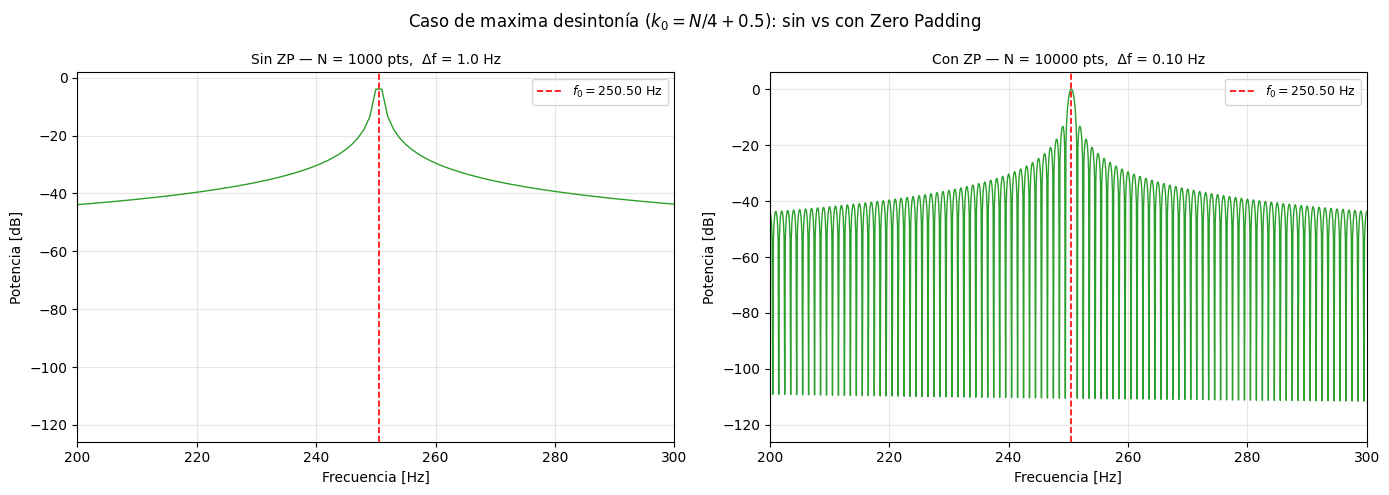

Potencia total sin ZP: 0.999998
Potencia total con ZP (corregida): 9.999980
Potencia tiempo:       1.000000


In [ ]:
s_max = senales[2]

f_fft, Pxx     = sig.periodogram(s_max, fs, window='boxcar', scaling='spectrum', nfft=N)
f_zp,  Pxx_zp  = sig.periodogram(s_max, fs, window='boxcar', scaling='spectrum', nfft=N_zp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(r'Caso de maxima desintonía ($k_0 = N/4 + 0.5$): sin vs con Zero Padding', fontsize=12)

for ax, f, Pxx_plot, titulo in zip(
        axes,
        [f_fft, f_zp],
        [Pxx,   Pxx_zp],
        [f'Sin ZP — N = {N} pts,  Δf = {fs/N:.1f} Hz',
         f'Con ZP — N = {N_zp} pts,  Δf = {fs/N_zp:.2f} Hz']):
    ax.plot(f, 10*np.log10(Pxx_plot + 1e-12), lw=1, color='C2')
    ax.axvline(k0_values[2]*df, color='red', linestyle='--', lw=1.2,
               label=f'$f_0 = {k0_values[2]*df:.2f}$ Hz')
    ax.set_xlim(200, 300)
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_ylabel('Potencia [dB]')
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

P_sin_zp = np.sum(Pxx)
P_con_zp = np.sum(Pxx_zp) * (N / N_zp)
print(f'Potencia total sin ZP: {P_sin_zp:.6f}')
print(f'Potencia total con ZP (corregida): {np.sum(Pxx_zp):.6f}')
print(f'Potencia tiempo:       {np.mean(np.abs(s_max)**2):.6f}')

### Discusion — Zero Padding

**Que hace el zero padding:**
El zero padding aumenta la cantidad de puntos de la DFT de $N$ a $N_{zp} = 10N$, lo que reduce la separacion entre bins a $\Delta f_{zp} = f_S / N_{zp} = 0.1$ Hz. Esto equivale a interpolar el espectro continuo (el espectro de la ventana convolucionado con el espectro de la senal) en una grilla mas densa.

**Que NO hace el zero padding:**
No mejora la resolucion espectral real: dos senoidales separadas por menos de $\Delta f = f_S/N = 1$ Hz siguen siendo indistinguibles, ya que la informacion disponible es la misma. Los lobulos secundarios del sinc siguen presentes con la misma altura.

**Resultado observado:**
- Para $k_0 = N/4$ (sintonizado): el zero padding confirma el pico puntual en $f_0 = 250$ Hz. Sin ZP el pico solo ocupaba un bin; con ZP se ve la forma del lobulo principal del sinc de Dirichlet, centrado en $f_0$.
- Para $k_0 = N/4 + 0.25$: se visualiza como el pico del sinc queda desplazado respecto de los bins originales.
- Para $k_0 = N/4 + 0.5$ (maxima desintonía): el zero padding revela claramente la forma del sinc de Dirichlet centrado exactamente entre dos bins. El pico real de la senal (a $f_0 = 250.5$ Hz) ahora es visible en el espectro interpolado, mostrando que el desparramo es consecuencia geometrica de muestrear el sinc en posiciones desfavorables.

**Conclusion:** el zero padding es una herramienta util para visualizar mejor el espectro y localizar picos, pero no reemplaza a la obtencion de mas datos reales para mejorar la resolucion espectral verdadera.